In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
MODEL_PATH = "/content/drive/MyDrive/RNN/final_efficientnetb0.keras"
IMAGE_DIR = "/content/drive/MyDrive/RNN/imagess"
OUTPUT_DIR = "/content/drive/MyDrive/RNN/external_test_results"

IMG_SIZE = (224, 224)
THRESHOLD = 0.5
CLASS_NAMES = ["fire", "no_fire"]

os.makedirs(OUTPUT_DIR, exist_ok=True)

model = load_model(MODEL_PATH)
print("Modèle chargé avec succès depuis :", MODEL_PATH)
print("Dossier images test :", IMAGE_DIR)
print("Dossier résultats   :", OUTPUT_DIR)

Modèle chargé avec succès depuis : /content/drive/MyDrive/RNN/final_efficientnetb0.keras
Dossier images test : /content/drive/MyDrive/RNN/imagess
Dossier résultats   : /content/drive/MyDrive/RNN/external_test_results


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 74 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [12]:
def list_image_files(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    folder = Path(folder)
    return [p for p in folder.rglob("*") if p.suffix.lower() in exts]

def infer_true_label_from_path(fp):
    path_str = str(fp).lower()

    # si l'image est dans .../fire/...
    if "/fire/" in path_str or "\\fire\\" in path_str:
        return 0

    # si l'image est dans .../no_fire/...
    if "/no_fire/" in path_str or "\\no_fire\\" in path_str:
        return 1

    return None

def predict_one_image(img_path):
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0).astype("float32")

    prob_no_fire = float(model.predict(arr, verbose=0)[0][0])
    prob_fire = 1.0 - prob_no_fire

    if prob_no_fire >= THRESHOLD:
        pred = 1
        pred_name = "no_fire"
        confidence = prob_no_fire
    else:
        pred = 0
        pred_name = "fire"
        confidence = prob_fire

    return {
        "prob_no_fire": prob_no_fire,
        "prob_fire": prob_fire,
        "pred": pred,
        "pred_name": pred_name,
        "confidence": confidence
    }

In [13]:
image_files = list_image_files(IMAGE_DIR)
print("Nombre total d'images trouvées :", len(image_files))

rows = []

for fp in image_files:
    pred_info = predict_one_image(str(fp))
    true_label = infer_true_label_from_path(fp)
    true_name = CLASS_NAMES[true_label] if true_label is not None else None

    rows.append({
        "filepath": str(fp),
        "filename": fp.name,
        "true_label": true_label,
        "true_name": true_name,
        "prob_no_fire": pred_info["prob_no_fire"],
        "prob_fire": pred_info["prob_fire"],
        "pred": pred_info["pred"],
        "pred_name": pred_info["pred_name"],
        "confidence": pred_info["confidence"]
    })

results_df = pd.DataFrame(rows)

if "true_label" in results_df.columns:
    results_df["correct"] = results_df.apply(
        lambda r: None if pd.isna(r["true_label"]) else int(r["true_label"] == r["pred"]),
        axis=1
    )

csv_path = os.path.join(OUTPUT_DIR, "external_predictions.csv")
results_df.to_csv(csv_path, index=False)

print("CSV des prédictions sauvegardé dans :", csv_path)
display(results_df.head(20))

Nombre total d'images trouvées : 87
CSV des prédictions sauvegardé dans : /content/drive/MyDrive/RNN/external_test_results/external_predictions.csv


,filepath,filename,true_label,true_name,prob_no_fire,prob_fire,pred,pred_name,confidence,correct
0,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.93.png,0,fire,8.369070e-05,0.999916,0,fire,0.999916,1
1,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.97.png,0,fire,3.628411e-05,0.999964,0,fire,0.999964,1
2,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.95.png,0,fire,2.323757e-07,1.000000,0,fire,1.000000,1
3,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.94.png,0,fire,2.138900e-08,1.000000,0,fire,1.000000,1
4,/content/drive/MyDrive/RNN/imagess/fire/fire.7...,fire.75.png,0,fire,7.406775e-07,0.999999,0,fire,0.999999,1
5,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.91.png,0,fire,1.017935e-01,0.898207,0,fire,0.898207,1
6,/content/drive/MyDrive/RNN/imagess/fire/fire.7...,fire.755.png,0,fire,6.451128e-06,0.999994,0,fire,0.999994,1
7,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.96.png,0,fire,5.530234e-05,0.999945,0,fire,0.999945,1
8,/content/drive/MyDrive/RNN/imagess/fire/fire.7...,fire.749.png,0,fire,3.658990e-09,1.000000,0,fire,1.000000,1
9,/content/drive/MyDrive/RNN/imagess/fire/fire.9...,fire.92.png,0,fire,4.636165e-07,1.000000,0,fire,1.000000,1


Nombre d'images évaluables : 87
Métriques :


,accuracy,precision,recall,f1_score
0,1.0,1.0,1.0,1.0


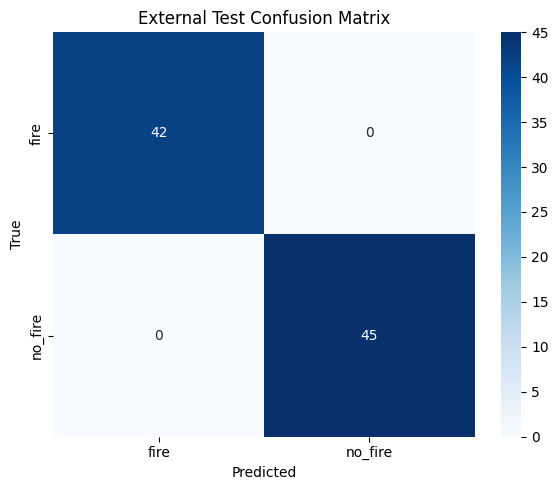


Classification report :

              precision    recall  f1-score   support

        fire       1.00      1.00      1.00        42
     no_fire       1.00      1.00      1.00        45

    accuracy                           1.00        87
   macro avg       1.00      1.00      1.00        87
weighted avg       1.00      1.00      1.00        87

Metrics CSV sauvegardé dans : /content/drive/MyDrive/RNN/external_test_results/external_metrics.csv
Classification report sauvegardé dans : /content/drive/MyDrive/RNN/external_test_results/external_classification_report.txt
Confusion matrix sauvegardée dans : /content/drive/MyDrive/RNN/external_test_results/external_confusion_matrix.png


In [14]:
eval_df = results_df.dropna(subset=["true_label"]).copy()
eval_df["true_label"] = eval_df["true_label"].astype(int)

print("Nombre d'images évaluables :", len(eval_df))

if len(eval_df) == 0:
    print("Aucun vrai label détecté. Vérifie que tes images sont bien dans fire/ et no_fire/.")
else:
    y_true = eval_df["true_label"].values
    y_pred = eval_df["pred"].values

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_csv = os.path.join(OUTPUT_DIR, "external_metrics.csv")
    metrics_df.to_csv(metrics_csv, index=False)

    print("Métriques :")
    display(metrics_df)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("External Test Confusion Matrix")
    plt.tight_layout()

    cm_path = os.path.join(OUTPUT_DIR, "external_confusion_matrix.png")
    plt.savefig(cm_path, dpi=220)
    plt.show()

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    report_path = os.path.join(OUTPUT_DIR, "external_classification_report.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_text)

    print("\nClassification report :\n")
    print(report_text)

    print("Metrics CSV sauvegardé dans :", metrics_csv)
    print("Classification report sauvegardé dans :", report_path)
    print("Confusion matrix sauvegardée dans :", cm_path)

In [15]:
mis_df = eval_df[eval_df["true_label"] != eval_df["pred"]].copy()
print("Nombre d'images mal classées :", len(mis_df))

display(mis_df.head(20))

Nombre d'images mal classées : 0


,filepath,filename,true_label,true_name,prob_no_fire,prob_fire,pred,pred_name,confidence,correct
